In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import os

In [5]:
base_dir = os.getcwd()
data2_dir = os.path.join(base_dir, 'Ex3', 'Practice', 'Practice2', 'elantra.csv')

In [6]:
df = pd.read_csv(data2_dir)

In [7]:
df.shape

(50, 7)

In [8]:
df

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
0,1,2010,7690,9.7,153,213.377,217.466
1,1,2011,9659,9.1,259,229.353,221.082
2,1,2012,10900,8.2,354,244.178,227.666
3,1,2013,12174,7.9,230,242.560,231.321
4,1,2014,15326,6.6,232,247.575,234.933
5,2,2010,7966,9.8,130,209.924,217.251
6,2,2011,12289,9.0,266,232.188,221.816
7,2,2012,13820,8.3,296,247.615,228.138
8,2,2013,16219,7.7,239,252.639,232.599
9,2,2014,16393,6.7,240,246.389,235.169


In [13]:
df = df.sort_values(by = ['Year','Month'])

In [14]:
df

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
0,1,2010,7690,9.7,153,213.377,217.466
5,2,2010,7966,9.8,130,209.924,217.251
10,3,2010,8225,9.9,138,209.163,217.305
14,4,2010,9657,9.9,132,209.024,217.376
18,5,2010,9781,9.6,177,206.172,217.299
22,6,2010,14245,9.4,138,204.161,217.285
26,7,2010,18215,9.5,156,206.834,217.677
30,8,2010,15181,9.5,202,208.927,218.012
34,9,2010,10062,9.5,150,209.850,218.281
38,10,2010,9497,9.5,178,216.655,219.024


In [16]:
df = df.reset_index(drop = True)

In [17]:
df

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
0,1,2010,7690,9.7,153,213.377,217.466
1,2,2010,7966,9.8,130,209.924,217.251
2,3,2010,8225,9.9,138,209.163,217.305
3,4,2010,9657,9.9,132,209.024,217.376
4,5,2010,9781,9.6,177,206.172,217.299
5,6,2010,14245,9.4,138,204.161,217.285
6,7,2010,18215,9.5,156,206.834,217.677
7,8,2010,15181,9.5,202,208.927,218.012
8,9,2010,10062,9.5,150,209.850,218.281
9,10,2010,9497,9.5,178,216.655,219.024


In [20]:
df['ElantraSales'].values

array([ 7690,  7966,  8225,  9657,  9781, 14245, 18215, 15181, 10062,
        9497,  8631, 13096,  9659, 12289, 19255, 22100, 20006, 19992,
       15181, 15054, 14386, 13000, 12414, 13025, 10900, 13820, 19681,
       16836, 18877, 17655, 18512, 17989, 18305, 14512, 15923, 19024,
       12174, 16219, 26153, 24445, 25090, 22163, 23958, 24700, 19691,
       14876, 16751, 21692, 15326, 16393])

Text(0, 0.5, 'Sales')

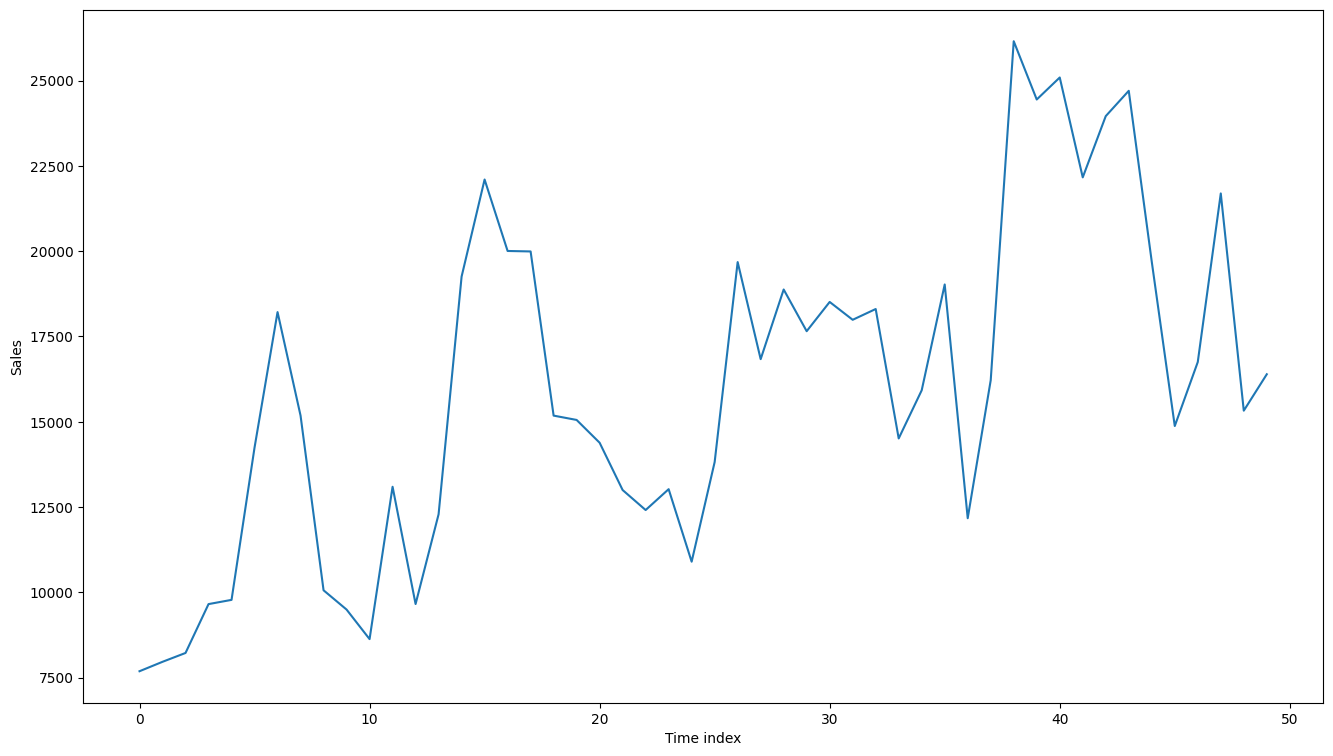

In [24]:
plt.figure(figsize = (16,9))
plt.plot(df['ElantraSales'].values)
plt.xlabel('Time index')
plt.ylabel('Sales')

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Month         50 non-null     int64  
 1   Year          50 non-null     int64  
 2   ElantraSales  50 non-null     int64  
 3   Unemployment  50 non-null     float64
 4   Queries       50 non-null     int64  
 5   CPI_energy    50 non-null     float64
 6   CPI_all       50 non-null     float64
dtypes: float64(3), int64(4)
memory usage: 2.9 KB


In [26]:
df


,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
0,1,2010,7690,9.7,153,213.377,217.466
1,2,2010,7966,9.8,130,209.924,217.251
2,3,2010,8225,9.9,138,209.163,217.305
3,4,2010,9657,9.9,132,209.024,217.376
4,5,2010,9781,9.6,177,206.172,217.299
5,6,2010,14245,9.4,138,204.161,217.285
6,7,2010,18215,9.5,156,206.834,217.677
7,8,2010,15181,9.5,202,208.927,218.012
8,9,2010,10062,9.5,150,209.850,218.281
9,10,2010,9497,9.5,178,216.655,219.024


In [28]:
numeric_feature = df.columns.drop(["ElantraSales", "Month", "Year"])
numeric_feature

Index(['Unemployment', 'Queries', 'CPI_energy', 'CPI_all'], dtype='str')

In [74]:
df_train = df[df['Year']<2013]
df_test = df[df['Year']>=2013]

y_train = df_train['ElantraSales'].values # chuyển về mảng 1d
y_test = df_test['ElantraSales'].values

In [75]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(df[numeric_feature])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [76]:
test = pd.DataFrame(sc.transform(df[numeric_feature]))

In [77]:
# sau khi chuẩn hóa sử dụng standard scaler thì mean và std thành 1
test.describe()

,0,1,2,3
count,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01
mean,1.216804e-15,-2.386980e-16,2.953193e-16,1.918465e-15
std,1.010153e+00,1.010153e+00,1.010153e+00,1.010153e+00
min,-1.934235e+00,-1.729055e+00,-2.151385e+00,-1.612934e+00
25%,-7.399351e-01,-5.016953e-01,-4.517141e-01,-9.304829e-01
50%,-1.825952e-01,-1.269459e-02,4.884095e-01,1.976992e-01
75%,7.197647e-01,6.155580e-01,6.638675e-01,8.421986e-01
max,1.569045e+00,2.118183e+00,1.275945e+00,1.433064e+00


In [78]:
# tập train và test chỉ bao gồm các cột có ý nghĩa số học, định lượng
X_train = sc.transform(df_train[numeric_feature])
X_test = sc.transform(df_test[numeric_feature])

In [79]:
# linear regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [80]:
from sklearn.metrics import mean_squared_error
def relative_error(y_true, y_pred):
    errors = np.abs(y_pred - y_true).astype(float) / y_true
    # sử dụng astype vì nó có thể áp dụng luôn cho cả 1 array nếu ép kiểu thông thường thì cần dùng loop
    return errors.mean()*100

In [81]:
y_pred_lr = lr.predict(X_test)
print(f"mean value of y_test: {y_test.mean()}")
print(f"rmse of lr_model: {np.sqrt(mean_squared_error(y_test, y_pred_lr))}")
print(f"mean relative error of lr_model: {relative_error(y_test,y_pred_lr)}%")


mean value of y_test: 19973.64285714286
rmse of lr_model: 5017.347620904413
mean relative error of lr_model: 18.959438416755887%


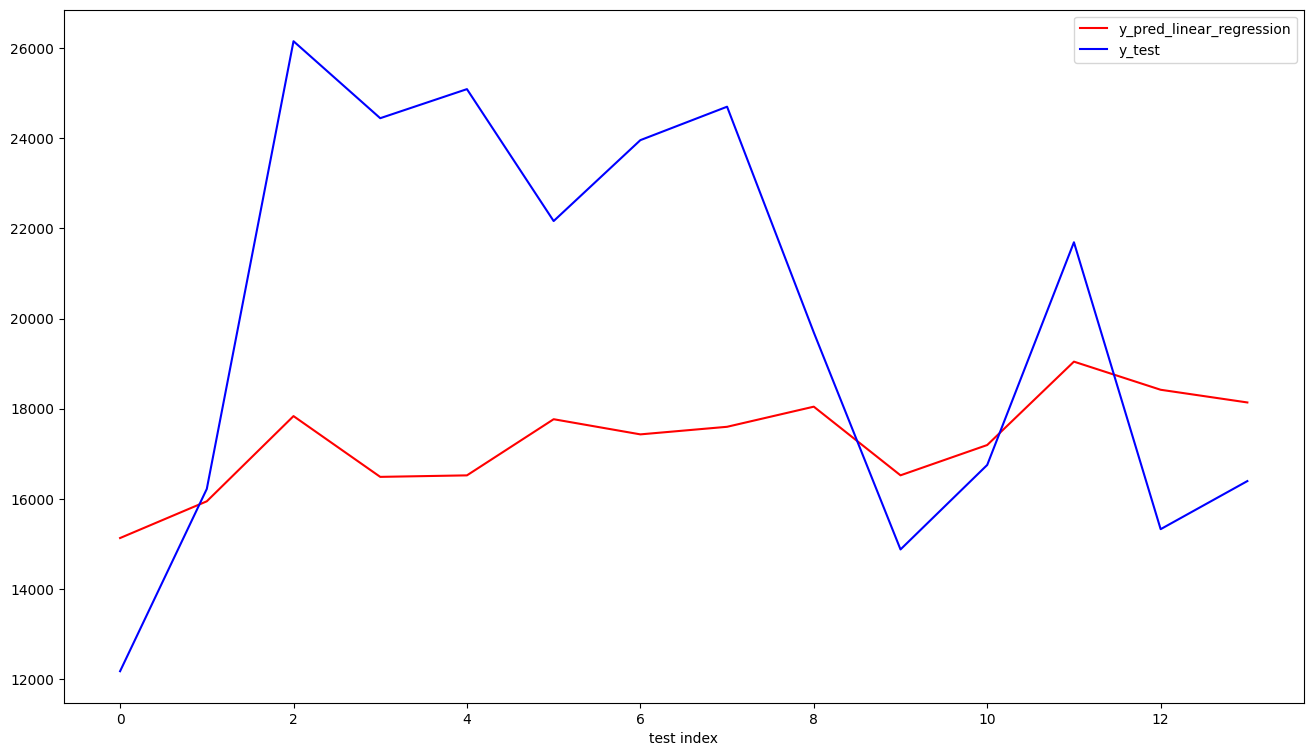

In [82]:
# biểu đồ của y_pred và y_test của lr
plt.figure(figsize = (16,9))
plt.xlabel('test index')
plt.plot(y_pred_lr, color = 'r', label = 'y_pred_linear_regression')
plt.plot(y_test, color = 'b' , label = 'y_test')
plt.legend()

In [83]:
# mô hình không fit vì ta đã bỏ đi thông tin quan trọng là tháng, là thông tin mang tính chất chu kì cao, có thể giải quyết bằng cách sử dụng onehot 
one_hot_month = np.array(pd.get_dummies(df_train['Month'],dtype = int))
one_hot_month.shape

(36, 12)

In [84]:
X_train.shape

(36, 4)

In [85]:
X_test.shape

(14, 4)

In [ ]:
# hstack: horizontal stack, vstack: vertical, đầu vào là tuple của list
X_train_one_hot = np.hstack((X_train, one_hot_month))
X_train_one_hot.shape

(36, 16)

In [95]:
X_test_one_hot = np.hstack((X_test, pd.get_dummies(df_test['Month'])))
X_test_one_hot.shape

(14, 16)

In [97]:
# train lại lr sử dụng onehot cho month
lr.fit(X_train_one_hot, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [99]:
y_pred_one_hot = lr.predict(X_test_one_hot)
print(f"mean value of y_test: {y_test.mean()}")
print(f"rmse of lr_model using one hot: {np.sqrt(mean_squared_error(y_test, y_pred_one_hot))}")
print(f"mean relative error of lr_model using one hot: {relative_error(y_test,y_pred_one_hot)}%")

mean value of y_test: 19973.64285714286
rmse of lr_model using one hot: 3590.3713401558252
mean relative error of lr_model using one hot: 12.782187866064227%


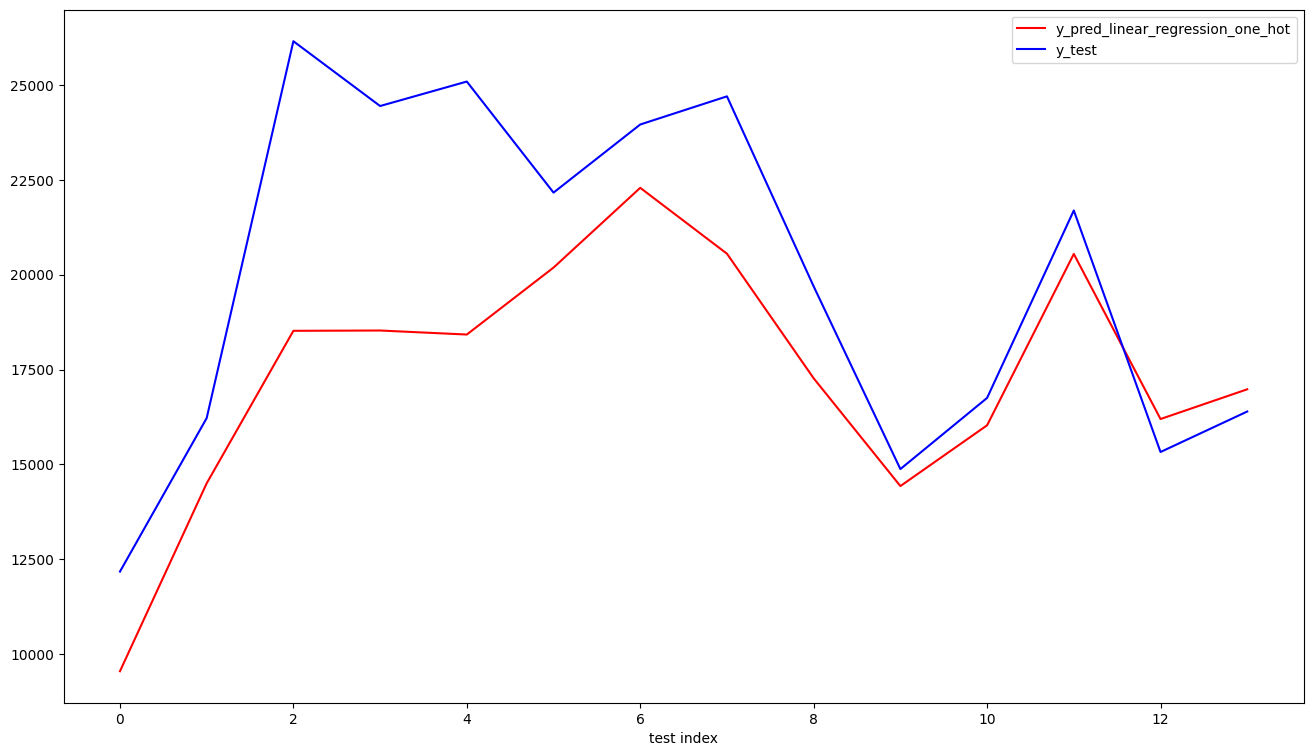

In [100]:
# biểu đồ của y_pred và y_test của lr sử dụng one hot cho month
plt.figure(figsize = (16,9))
plt.xlabel('test index')
plt.plot(y_pred_one_hot, color = 'r', label = 'y_pred_linear_regression_one_hot')
plt.plot(y_test, color = 'b' , label = 'y_test')
plt.legend()